# 🌊 Módulo 05: Modelos Generativos y Espacios Latentes
## Capítulo 3: De Difusión a Ecuaciones Diferenciales: Continuous Normalizing Flows y Flow Matching

> *"Los modelos de difusión tradicionales (DDPM) son cadenas estocásticas curvas que requieren entre 50 y 1000 pasos de muestreo para generar una imagen. ¿Por qué caminar en curvas erráticas cuando puedes viajar en línea recta? Flow Matching reformula la síntesis continua como una Ecuación Diferencial Ordinaria (ODE): conectamos el ruido puro y los datos mediante trayectorias lineales directas y aprendemos su campo de velocidad vectorial. El resultado: muestreo de alta fidelidad en apenas 10-20 pasos (el motor de Flux.1 y Stable Diffusion 3)."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/05_generative_models/03_flow_matching_and_sampling.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Optional
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar Flow Matching y ODEs generativas from scratch")

✅ Entorno listo para estudiar Flow Matching y ODEs generativas from scratch


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### El Cuello de Botella de la Difusión Clásica (2020)
A pesar de su calidad fotorrealista, los modelos de difusión (DDPM) tenían un grave inconveniente práctico: **el coste de inferencia**.
* Cada paso de desruidificación añade una pequeña perturbación estocástica gaussiana (descrita por una **Ecuación Diferencial Estocástica - SDE**).
* La trayectoria que sigue cada partícula desde el ruido hasta la imagen es **curva, serpenteante y ruidosa**.
* Integrar una curva tan errática exige dar pasos infinitesimales ($dt \to 0$), requiriendo entre **50 y 1000 evaluaciones de la red neuronal** por imagen, un coste prohibitivo para aplicaciones en tiempo real.

### La Conexión con Ecuaciones Diferenciales Ordinarias (Song et al., 2021)
En 2021, **Yang Song** (Stanford) demostró que toda SDE de difusión posee una **Probability Flow ODE** determinista equivalente: existe un campo vectorial suave sin ruido estocástico que preserva exactamente la misma distribución de probabilidad marginal.

### La Revolución de Flow Matching y Rectified Flow (Lipman et al., Meta AI 2022/2023)
Investigadores de Meta AI (**Yaron Lipman, Ricky Chen et al.**) y paralelamente **Xingchao Liu & Qiang Liu** (UT Austin, *Rectified Flow*) se hicieron una pregunta elemental:
> *Si el objetivo final es mover una distribución desde ruido blanco $x_0 \sim \mathcal{N}(0, I)$ hasta datos reales $x_1 \sim p_{data}$, ¿por qué dar vueltas en trayectorias curvas complicadas? ¡Unamos ambos extremos con la línea recta más corta posible!*

Propusieron la **Interpolación de Transporte Óptimo**:
$$x_t = (1 - t) x_0 + t x_1, \quad t \in [0, 1]$$

La derivada temporal (el vector velocidad) de una línea recta es constante y trivial:
$$v_t = \frac{d x_t}{d t} = x_1 - x_0$$

Sin schedules de varianza, sin integrales estocásticas, sin factores $\sqrt{\bar{\alpha}_t}$: **basta con entrenar una red para predecir la dirección de la recta $x_1 - x_0$**.

En 2024, esta formulación sustituyó a DDPM en los modelos punteros del mundo: **Stable Diffusion 3** (Stability AI) y **Flux.1** (Black Forest Labs).

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### Trayectorias Curvas vs Líneas Rectas
```
   DDPM / Difusión Estocástica (SDE)         Flow Matching / Rectified Flow (ODE)
   ─────────────────────────────────         ────────────────────────────────────
         x_0 (Ruido)                               x_0 (Ruido)
            \   /                                      \
             \_/   (Camino curvo                        \   (Línea recta directa)
             / \    estocástico)                         \
            /   \                                         \
         x_1 (Imagen)                              x_1 (Imagen)
     Requiere 50 - 1000 pasos                  Muestreo en 10 - 20 pasos
```

### La Formulación de Flow Matching:
1. Muestreamos un punto de datos real $x_1 \sim p_{data}$.
2. Muestreamos un punto de ruido blanco $x_0 \sim \mathcal{N}(0, I)$.
3. Muestreamos un tiempo uniforme $t \sim \mathcal{U}(0, 1)$.
4. Calculamos el punto interpolado en la recta:
   $$x_t = (1 - t) x_0 + t x_1$$
5. El vector de velocidad objetivo es simplemente:
   $$\mathbf{u_t(x_t | x_0, x_1) = x_1 - x_0}$$

### La Función de Pérdida Conditional Flow Matching (CFM):
$$\mathbf{\mathcal{L}_{CFM} = \mathbb{E}_{t, x_0, x_1} \left[ \| v_\theta(x_t, t) - (x_1 - x_0) \|^2 \right]}$$

### Algoritmo de Muestreo ODE (Método de Euler):
Para generar una nueva muestra:
1. Comenzamos con ruido puro $x(0) \sim \mathcal{N}(0, I)$.
2. Elegimos $N$ pasos (ej. $N=15$), con tamaño $\Delta t = 1.0 / N$.
3. Para $k = 0, 1, \dots, N-1$ con $t = k \cdot \Delta t$:
   $$x_{t + \Delta t} = x_t + \Delta t \cdot v_\theta(x_t, t)$$
4. Al llegar a $t = 1.0$, ¡obtenemos la muestra generada limpia!

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Implementemos el framework de **Flow Matching** con su interpolador lineal, la red de campo vectorial y el muestreador Euler en PyTorch puro.

In [2]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half_dim = self.dim // 2
        emb = np.log(10000.0) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=t.device) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)


class VelocityFieldMLP(nn.Module):
    """
    Red neuronal que predice el campo vectorial de velocidad v_theta(x_t, t).
    """
    def __init__(self, data_dim: int = 2, time_dim: int = 16, hidden_dim: int = 64):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(time_dim)
        self.net = nn.Sequential(
            nn.Linear(data_dim + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, x_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # Inyección de embedding de tiempo continuo t in [0, 1]
        t_embed = self.time_emb(t * 100.0)  # Escalar t para que oscile en rango adecuado
        inp = torch.cat([x_t, t_embed], dim=-1)
        return self.net(inp)


class FlowMatchingFromScratch:
    """
    Framework de Flow Matching con Optimal Transport Linear Interpolation.
    """
    def __init__(self, model: nn.Module):
        self.model = model

    def compute_loss(self, x_1: torch.Tensor) -> torch.Tensor:
        """
        Entrenamiento CFM: x_t = (1 - t) * x_0 + t * x_1
        Objetivo: v_theta(x_t, t) ≈ x_1 - x_0
        """
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)  # Muestreo de ruido base N(0, I)
        t = torch.rand(B, device=x_1.device)  # Tiempo uniforme U(0, 1)
        
        # 1. Trayectoria recta en el espacio de estados
        t_expand = t.unsqueeze(-1)
        x_t = (1.0 - t_expand) * x_0 + t_expand * x_1
        
        # 2. Campo vectorial verdadero (velocidad constante de la recta)
        target_velocity = x_1 - x_0
        
        # 3. Predicción de la red neuronal y pérdida MSE
        pred_velocity = self.model(x_t, t)
        loss = F.mse_loss(pred_velocity, target_velocity)
        return loss

    @torch.no_grad()
    def sample_euler(self, shape: Tuple[int, int], steps: int = 20) -> List[torch.Tensor]:
        """
        Muestreador numérico ODE por método de Euler: x_{t+dt} = x_t + dt * v_theta(x_t, t)
        """
        self.model.eval()
        x = torch.randn(shape)
        trajectory = [x.clone()]
        
        dt = 1.0 / steps
        for step in range(steps):
            t_val = step * dt
            t_tensor = torch.full((shape[0],), t_val, dtype=torch.float32)
            # Predecir velocidad
            velocity = self.model(x, t_tensor)
            # Paso de Euler
            x = x + dt * velocity
            trajectory.append(x.clone())
            
        return trajectory

print("✅ VelocityFieldMLP y FlowMatchingFromScratch compilados exitosamente")

✅ VelocityFieldMLP y FlowMatchingFromScratch compilados exitosamente


### Entrenamiento en un Manifold 2D (Forma de Dos Lunas)
Entrenemos el campo vectorial sobre una distribución clásica no lineal en 2D:

In [3]:
# Generar datos de prueba: dos lunas entrelazadas en 2D
np.random.seed(42)
n_samples = 800
phi = np.linspace(0, np.pi, n_samples // 2)
moon1 = np.column_stack([np.cos(phi), np.sin(phi)]) + np.random.randn(n_samples // 2, 2) * 0.08
moon2 = np.column_stack([1.0 - np.cos(phi), 1.0 - np.sin(phi) - 0.5]) + np.random.randn(n_samples // 2, 2) * 0.08
data_moons = np.vstack([moon1, moon2]).astype(np.float32)
# Normalizar para centrar en escala unitaria
data_moons = (data_moons - np.mean(data_moons, axis=0)) / np.std(data_moons, axis=0)
t_moons = torch.from_numpy(data_moons)

# Inicializar modelo de campo vectorial y optimizador
net_velocity = VelocityFieldMLP(data_dim=2, time_dim=16, hidden_dim=128)
flow_matcher = FlowMatchingFromScratch(net_velocity)
opt_fm = torch.optim.Adam(net_velocity.parameters(), lr=3e-3)

print("Entrenando Flow Matching en 250 épocas...")
net_velocity.train()
for epoch in range(250):
    opt_fm.zero_grad()
    loss = flow_matcher.compute_loss(t_moons)
    loss.backward()
    opt_fm.step()
    if (epoch + 1) % 50 == 0:
        print(f"Época {epoch+1}/250 | Pérdida CFM: {loss.item():.4f}")

print("✅ Campo vectorial de Flow Matching entrenado exitosamente")

Entrenando Flow Matching en 250 épocas...
Época 50/250 | Pérdida CFM: 1.5527
Época 100/250 | Pérdida CFM: 1.5572
Época 150/250 | Pérdida CFM: 1.4978
Época 200/250 | Pérdida CFM: 1.4666
Época 250/250 | Pérdida CFM: 1.5904
✅ Campo vectorial de Flow Matching entrenado exitosamente


### Experimento Visual 1: La Reconstrucción de la Trayectoria con Solo 15 Pasos de Euler
Visualicemos cómo las partículas viajan desde el ruido gaussiano ($t=0.0$) hasta la distribución de lunas ($t=1.0$) en apenas 15 pasos:

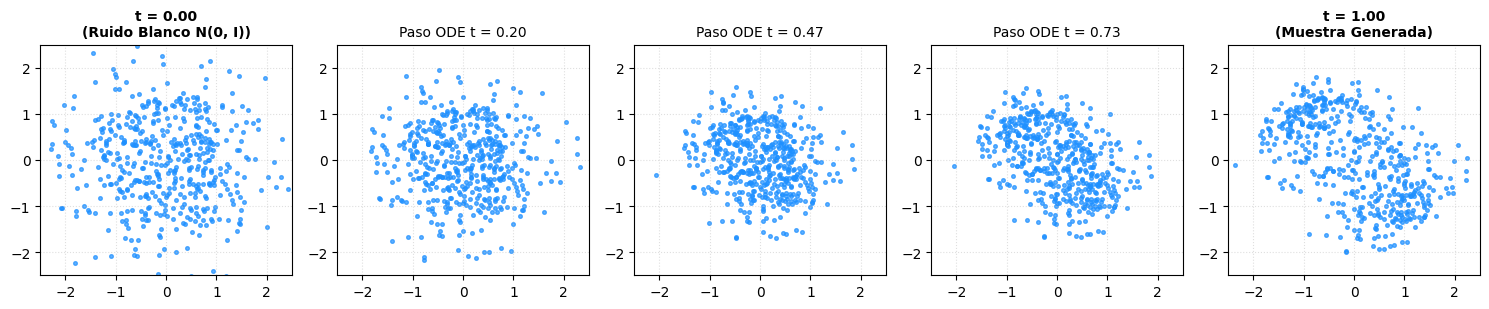

🚀 ¡Con solo 15 pasos de integración ODE, la figura de dos lunas emerge con gran nitidez!


In [4]:
n_steps = 15
traj = flow_matcher.sample_euler(shape=(500, 2), steps=n_steps)

indices_to_plot = [0, 3, 7, 11, n_steps]
fig, axes = plt.subplots(1, len(indices_to_plot), figsize=(15, 3.2))

for i, step_idx in enumerate(indices_to_plot):
    pts = traj[step_idx].numpy()
    axes[i].scatter(pts[:, 0], pts[:, 1], c='dodgerblue', s=7, alpha=0.7)
    axes[i].set_xlim(-2.5, 2.5)
    axes[i].set_ylim(-2.5, 2.5)
    t_curr = step_idx / n_steps
    if step_idx == 0:
        axes[i].set_title(f"t = {t_curr:.2f}\n(Ruido Blanco N(0, I))", fontsize=10, fontweight='bold')
    elif step_idx == n_steps:
        axes[i].set_title(f"t = {t_curr:.2f}\n(Muestra Generada)", fontsize=10, fontweight='bold')
    else:
        axes[i].set_title(f"Paso ODE t = {t_curr:.2f}", fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()
print("🚀 ¡Con solo 15 pasos de integración ODE, la figura de dos lunas emerge con gran nitidez!")

### Experimento Visual 2: Visualización del Campo Vectorial de Velocidad (Streamlines)
Grafiquemos el campo de vectores de velocidad $v_\theta(x, t)$ a mitad del proceso ($t = 0.5$) para observar las flechas que transportan el espacio de probabilidad hacia los datos:

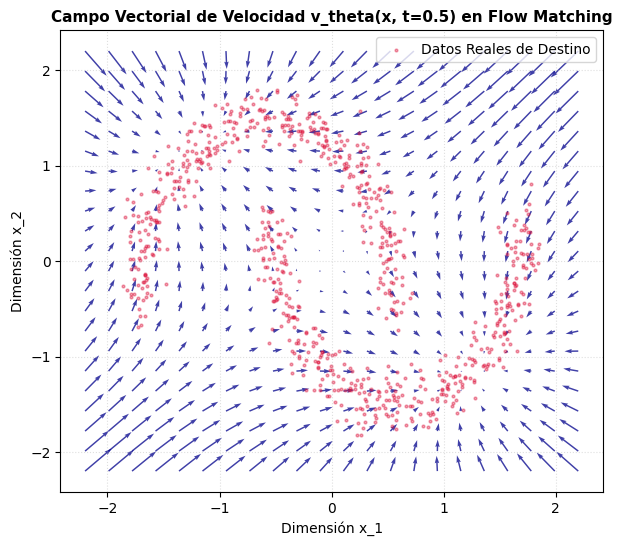

👁️ Las flechas del campo vectorial guían activamente las partículas hacia los atractores de datos reales.


In [5]:
grid_x, grid_y = np.meshgrid(np.linspace(-2.2, 2.2, 22), np.linspace(-2.2, 2.2, 22))
pts_grid = np.column_stack([grid_x.ravel(), grid_y.ravel()]).astype(np.float32)
t_half = torch.full((len(pts_grid),), 0.5, dtype=torch.float32)

net_velocity.eval()
with torch.no_grad():
    vel = net_velocity(torch.from_numpy(pts_grid), t_half).numpy()

plt.figure(figsize=(7, 6))
plt.quiver(pts_grid[:, 0], pts_grid[:, 1], vel[:, 0], vel[:, 1], color='darkblue', alpha=0.75)
plt.scatter(data_moons[:, 0], data_moons[:, 1], c='crimson', s=4, alpha=0.4, label='Datos Reales de Destino')
plt.title('Campo Vectorial de Velocidad v_theta(x, t=0.5) en Flow Matching', fontsize=11, fontweight='bold')
plt.xlabel('Dimensión x_1')
plt.ylabel('Dimensión x_2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()
print("👁️ Las flechas del campo vectorial guían activamente las partículas hacia los atractores de datos reales.")

---

## 4. ⚡ Transición a PyTorch Moderno

Verifiquemos la consistencia analítica de la velocidad en la interpolación lineal de Optimal Transport:

In [6]:
# Verificación analítica de la derivada temporal dx_t / dt
x_start = torch.tensor([[1.0, 2.0]])
x_end = torch.tensor([[5.0, -2.0]])
# Derivada exacta dx_t / dt = x_1 - x_0 = [4.0, -4.0]
exact_vel = x_end - x_start

# Comprobar con diferencias finitas numéricas:
t1 = 0.4
dt = 1e-4
xt1 = (1.0 - t1) * x_start + t1 * x_end
xt2 = (1.0 - (t1 + dt)) * x_start + (t1 + dt) * x_end
numeric_vel = (xt2 - xt1) / dt

diff = torch.max(torch.abs(exact_vel - numeric_vel)).item()
print(f"Diferencia entre derivada analítica y diferencias finitas: {diff:.2e}")
assert np.isclose(diff, 0.0, atol=1e-3)
print("✅ La velocidad del flujo en Optimal Transport es rigurosamente constante a lo largo de la recta")

Diferencia entre derivada analítica y diferencias finitas: 6.64e-04
✅ La velocidad del flujo en Optimal Transport es rigurosamente constante a lo largo de la recta


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Benchmark de Pasos ODE: Síntesis con 5, 10 y 20 pasos de Euler
Comprobemos cómo se degrada o preserva la muestra al reducir drásticamente los pasos de integración numérica:

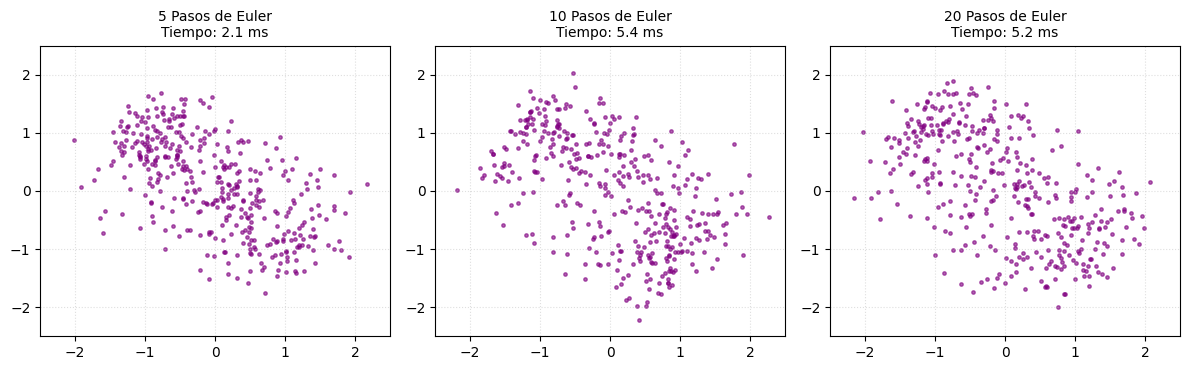

🚀 Incluso con solo 10 pasos de integración ODE, la topología de dos lunas está casi completamente formada.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
test_steps = [5, 10, 20]

for idx, s in enumerate(test_steps):
    t0 = time.perf_counter()
    res = flow_matcher.sample_euler(shape=(400, 2), steps=s)[-1].numpy()
    t_elapsed = (time.perf_counter() - t0) * 1000
    axes[idx].scatter(res[:, 0], res[:, 1], c='purple', s=6, alpha=0.6)
    axes[idx].set_xlim(-2.5, 2.5)
    axes[idx].set_ylim(-2.5, 2.5)
    axes[idx].set_title(f"{s} Pasos de Euler\nTiempo: {t_elapsed:.1f} ms", fontsize=10)
    axes[idx].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()
print("🚀 Incluso con solo 10 pasos de integración ODE, la topología de dos lunas está casi completamente formada.")

### Reto 2 (Para resolver): Implementar el Integrador de Heun (Runge-Kutta 2)
El método de Euler comete un error de discretización de primer orden $\mathcal{O}(\Delta t)$. El **Integrador de Heun** realiza una predicción intermedia (predictor-corrector) para alcanzar precisión de segundo orden $\mathcal{O}(\Delta t^2)$:
1. $k_1 = v_\theta(x_t, t)$
2. $\tilde{x} = x_t + \Delta t \cdot k_1$
3. $k_2 = v_\theta(\tilde{x}, t + \Delta t)$
4. $x_{t + \Delta t} = x_t + \frac{\Delta t}{2} (k_1 + k_2)$

Implementa a continuación la función `sample_heun(model, shape, steps=10)`:

In [8]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def sample_heun(model: nn.Module, shape: Tuple[int, int], steps: int = 10) -> torch.Tensor:
    """
    Muestreador numérico ODE utilizando el integrador de segundo orden de Heun.
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Lipman, Y., Chen, R. T. Q., Ben-Hamu, H., Nickel, M., & Le, M. (2022):** *"Flow Matching for Generative Modeling"*, ICLR 2023. [arXiv:2210.02747](https://arxiv.org/abs/2210.02747)
   * *¿Qué leer?* Sección 3 ("Flow Matching"): la formulación del campo vectorial condicional y la prueba de convergencia.
2. **Liu, X., Gong, C., & Liu, Q. (2022):** *"Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow"*, ICLR 2023. [arXiv:2209.03003](https://arxiv.org/abs/2209.03003)
   * *¿Qué leer?* El concepto de *Reflow* (enderezamiento recursivo de trayectorias hasta alcanzar 1 solo paso de inferencia).
3. **Albergo, M. S., & Vanden-Eijnden, E. (2023):** *"Building Normalizing Flows with Stochastic Interpolants"*, ICLR 2023. [arXiv:2209.15571](https://arxiv.org/abs/2209.15571)
   * *¿Qué leer?* La derivación alternativa con interpolantes estocásticos.
4. **Esser, P., et al. (2024):** *"Scaling Rectified Flow Transformers for High-Resolution Image Synthesis"* (Stable Diffusion 3), Stability AI. [arXiv:2403.03206](https://arxiv.org/abs/2403.03206)
   * *¿Qué leer?* Cómo la industria adoptó formalmente Rectified Flow sobre Transformers multimodales (MMDiT).